# 03 · Zincir Kuralı ve Backpropagation
**Calculus Lab** — Derin Öğrenmenin Matematiksel Kalbi

---
> **Bu notebook'ta ekstra özenle duracağız.** Şu ana kadar öğrendiğin her şey
> (`probability-lab`'daki MLE, `linear-algebra-lab`'daki regularizasyon, bu serideki
> gradyan/Hessian) bir modeli **tanımlamak** içindi. Ama bir model NASIL "öğreniyor"?
> Cevap: **backpropagation.** Bugün var olan hemen hemen her derin öğrenme modeli — büyük
> dil modelleri, görüntü tanıma ağları, senin ileride kuracağın herhangi bir sinir ağı —
> parametrelerini TAM OLARAK bu notebook'ta öğreneceğimiz algoritmayla güncelliyor. Bu,
> abartısız, derin öğrenmenin "çalışan motorunun" kendisi. Diğer her şey (mimari
> tasarımı, katman türleri, aktivasyon fonksiyonları) bu motorun üzerine inşa ediliyor.

**Önkoşul:** Türev/Gradyan (01), Jacobian/Hessian/Konvekslik (02)  
**Veri:**  
- `titanic` — Seaborn'a yerleşik (891 yolcu, hayatta kalma tahmini için)  
**Araçlar:** Python (`sympy`, `numpy`, `PyTorch`, `matplotlib`)

---
## 1 · Zincir Kuralı: En Basit Haliyle

Bir "makine hattı" düşün: birinci makine hammaddeyi işleyip yarı-mamul üretiyor, ikinci
makine bu yarı-mamulü alıp NİHAİ ürünü üretiyor. Yani ikinci makinenin GİRDİSİ, birinci
makinenin ÇIKTISI. Matematikte buna **bileşke fonksiyon** deniyor: $f(g(x))$ — önce $x$'e
$g$ uygulanıyor, sonra sonuca $f$ uygulanıyor.

**Soru:** $x$'i çok küçük değiştirirsem, NİHAİ çıktı ($f(g(x))$) ne kadar değişir? Bunu
bulmak için "zincir kuralı" kullanıyoruz:

$$\frac{d}{dx}f(g(x)) = f'(g(x)) \cdot g'(x)$$

**Sezgisi:** $x$'teki küçük bir değişiklik, ÖNCE $g$'yi ne kadar değiştiriyor ($g'(x)$
kadar), SONRA bu değişiklik $f$'yi ne kadar değiştiriyor ($f'(g(x))$ kadar) — iki etkiyi
ÇARPARAK toplam etkiyi buluyorsun. Tıpkı bir dişli sisteminde, birinci dişlinin
dönüşünün ikinci dişliye "aktarılması" gibi.

---
## 2 · Somut Sayısal Örnek: Adım Adım Zincir Kuralı

$h(x) = (3x+1)^2$ fonksiyonunun türevini bulalım. Bunu $f(g(x))$ olarak ayıralım:
- İç fonksiyon: $g(x) = 3x+1$
- Dış fonksiyon: $f(u) = u^2$ (burada $u=g(x)$)

**Adım 1 — Her parçanın türevini AYRI AYRI al:**
$$g'(x) = 3 \qquad f'(u) = 2u$$

**Adım 2 — Zincir kuralıyla çarp:**
$$h'(x) = f'(g(x)) \cdot g'(x) = 2(3x+1) \cdot 3 = 6(3x+1) = 18x+6$$

**Doğrulama (açarak):** $h(x)=(3x+1)^2=9x^2+6x+1$, doğrudan türevi $h'(x)=18x+6$ —
BİREBİR aynı sonuç! Zincir kuralı, bileşke bir fonksiyonu "açmadan" türev almanı
sağlıyor — büyük ifadeler için bu hayat kurtarıyor.

---
## 3 · Neden Sinir Ağları İçin Bu Kadar Önemli?

**En basit sinir ağını (tek nöron) düşün:** Bir girdi $x$ alıyor, onu bir ağırlıkla
çarpıp bir sapma (bias) ekliyor ($z = wx+b$), sonra bir aktivasyon fonksiyonundan
geçiriyor ($\hat{y}=\sigma(z)$), sonra bu tahminin gerçek değerden ($y$) ne kadar uzak
olduğunu bir loss fonksiyonuyla ölçüyor ($L=(\hat{y}-y)^2$).

**Fark ettin mi?** Bu tam olarak Bölüm 1'deki "makine hattı" — $x \to z \to \hat{y} \to L$,
her adım bir öncekinin çıktısını girdi olarak alıyor. Yani **bir sinir ağının loss'u,
ağırlıklara göre KATMAN KATMAN İÇ İÇE GEÇMİŞ bir bileşke fonksiyondur.** Ağırlığı
($w$) NASIL güncellemeliyim sorusunun cevabı, $\frac{\partial L}{\partial w}$'yi bulmak —
ve bunu bulmanın TEK yolu, zincir kuralını ÜÇ kez art arda uygulamak.

---
## 4 · İleri Yayılım (Forward Pass)

Bir sinir ağını "çalıştırmanın" ilk adımı — girdiden başlayıp SIRAYLA loss'a kadar ilerlemek:
$$x \xrightarrow{\times w, +b} z \xrightarrow{\sigma(\cdot)} \hat{y} \xrightarrow{(\hat{y}-y)^2} L$$

Her okun üzerinde bir işlem var, her adımda bir ara sonuç saklıyoruz ($z$, $\hat{y}$) —
bunlara **ihtiyacımız olacak**, çünkü Bölüm 5'te geriye doğru giderken bu ara değerleri
kullanacağız.

---
## 5 · Geri Yayılım (Backpropagation): Zincir Kuralının SİSTEMATİK Uygulanması

**Backpropagation, aslında yeni bir matematiksel kavram DEĞİL** — sadece zincir kuralını
ağın SONUNDAN (loss) BAŞINA (ağırlıklar) doğru, SİSTEMATİK bir şekilde uygulama yöntemi.
"Geriye doğru" gitmemizin sebebi: $\frac{\partial L}{\partial w}$'yi bulmak için önce
$\frac{\partial L}{\partial \hat{y}}$'ye, sonra $\frac{\partial \hat{y}}{\partial z}$'ye, sonra
$\frac{\partial z}{\partial w}$'ye ihtiyacımız var — ve bunların HER BİRİ, kendisinden
SONRAKİ (loss'a daha yakın) adımın sonucuna bağlı. Bu yüzden loss'tan başlayıp geriye
doğru "zinciri takip ediyoruz":

$$\frac{\partial L}{\partial w} = \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{1. adım}} \cdot \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\text{2. adım}} \cdot \underbrace{\frac{\partial z}{\partial w}}_{\text{3. adım}}$$

Bölüm 6'da bu üç adımı GERÇEK sayılarla, hiç atlamadan hesaplayacağız.

---
## 6 · Tek Nöronlu Ağda Backprop: TAM Adım Adım, Gerçek Sayılarla

Somut değerler: $x=2$, $w=0.5$, $b=0.1$, gerçek etiket $y=1$. Aktivasyon fonksiyonu
sigmoid: $\sigma(z)=\frac{1}{1+e^{-z}}$.

**İLERİ YAYILIM (Bölüm 4'ten):**
$$z = wx+b = 0.5(2)+0.1 = 1.1$$
$$\hat{y} = \sigma(1.1) = \frac{1}{1+e^{-1.1}} \approx 0.7503$$
$$L = (\hat{y}-y)^2 = (0.7503-1)^2 \approx 0.0624$$

**GERİ YAYILIM (Bölüm 5'teki üç adımı uyguluyoruz):**

**Adım 1** — $L=(\hat{y}-y)^2$'nin $\hat{y}$'ye göre türevi (üs kuralı + zincir kuralı):
$$\frac{\partial L}{\partial \hat{y}} = 2(\hat{y}-y) = 2(0.7503-1) \approx -0.4995$$

**Adım 2** — Sigmoid'in KENDİ türevi (çok kullanışlı bir özelliği var: $\sigma'(z)=\sigma(z)(1-\sigma(z))$):
$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1-\hat{y}) = 0.7503(1-0.7503) \approx 0.1874$$

**Adım 3** — $z=wx+b$'nin $w$'ye göre türevi ($b$ ve $x$ sabit kabul edilir):
$$\frac{\partial z}{\partial w} = x = 2$$

**HEPSİNİ ÇARP (zincir kuralı):**
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w} = (-0.4995)(0.1874)(2) \approx -0.1872$$

Bu sayı bize NE anlatıyor? $w$'yi artırırsam $L$ AZALIR (türev negatif) — yani gradient
descent (04'te göreceğiz) bu bilgiyi kullanıp $w$'yi bu yönde güncelleyecek. Aşağıda
bunu kodla ve `sympy`'yle doğrulayacağız.

---
## 7 · Hesaplama Grafiği (Computational Graph)

Yukarıdaki süreci bir **diyagram** olarak düşünmek çok yardımcı oluyor — her işlem bir
"düğüm", her ok bir "bağlantı":

$$x \to [\times w, +b] \to z \to [\sigma] \to \hat{y} \to [(\cdot-y)^2] \to L$$

**İleri yayılım:** Bu grafikte SOLDAN SAĞA git, her düğümde işlemi uygula.  
**Geri yayılım:** SAĞDAN SOLA git, her düğümde "bu düğümün girdisine göre çıktının türevini"
hesapla ve BİRİKTİREREK çarp (Bölüm 6'daki üç adım). Modern derin öğrenme kütüphaneleri
(PyTorch, TensorFlow) TAM OLARAK bunu otomatik yapıyor — her işlemi bu grafiğe kaydedip,
`.backward()` çağırdığında grafiği geriye doğru gezip zincir kuralını senin yerine
uyguluyorlar. Python 4'te bunu göreceğiz.

---
## 8 · Çok Katmanlı Ağda Zincir Nasıl Uzuyor?

Tek nöron yerine 2 katmanlı bir ağ düşün: $x \to z_1 \to a_1 \to z_2 \to \hat{y} \to L$.
İlk katmandaki bir ağırlığın ($w_1$) gradyanını bulmak için zincir artık DAHA UZUN:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}$$

**Kritik gözlem:** İlk üç terim ($\frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1}$),
SON katmandaki hesaplamanın **AYNISI** — tekrar hesaplamana gerek yok, zaten hesapladığın
"loss'a göre gradyanı" bir SONRAKİ katmana "aktarabiliyorsun". Bu, backpropagation'ın
NEDEN verimli olduğunun sırrı — her katmanda sıfırdan başlamak yerine, bir önceki
katmandan gelen bilgiyi (gradyanı) **geri kullanıyorsun.** 20 katmanlı bir ağda da mantık
birebir aynı, sadece zincir daha uzun.

---
## 9 · Özet Tablo

| Kavram | Ne Yapıyor |
|---|---|
| İleri Yayılım | Girdiden loss'a, SOLDAN SAĞA hesaplama |
| Geri Yayılım | Loss'tan ağırlıklara, SAĞDAN SOLA zincir kuralı uygulama |
| Zincir Kuralı | $\frac{\partial L}{\partial w}$'yi ara adımların türevlerinin ÇARPIMI olarak bulma |
| Hesaplama Grafiği | İşlemlerin sırasını/bağımlılığını gösteren diyagram |
| Otomatik Türev (Autograd) | PyTorch/TensorFlow'un bu süreci senin yerine yapması |

---
# 🐍 Python Uygulaması

6 adımda ilerleyeceğiz (bu notebook serinin en kritik konusu olduğu için kapsamlı):
1. **Zincir Kuralını Doğrulama** — Bölüm 2'deki örneği `sympy` ile kanıtlama
2. **Tek Nöron Backprop: Tam Elle** — Bölüm 6'daki hesabı kodla tekrarlama
3. **Gradyan Kontrolü (Gradient Checking)** — Elle türetilen gradyanın DOĞRU olduğunu kanıtlamanın standart yöntemi
4. **Gerçek Veride Mini Ağ: NumPy ile Sıfırdan Backprop** — Titanic'te
5. **Aynı Ağ, PyTorch `autograd` ile** — Kütüphanesiz ve kütüphaneli sonuçların birebir örtüşmesi
6. **3 Katmanlı Ağda Zincirin Uzaması**

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🔗 Python 1 — Zincir Kuralını Doğrulama: `sympy` ile

**Ne yapıyoruz?**  
Bölüm 2'deki $h(x)=(3x+1)^2$ örneğini `sympy` ile hesaplayıp elle bulduğumuz
$h'(x)=18x+6$ sonucunu doğruluyoruz.

In [2]:
x = sp.symbols('x')

h = (3*x + 1)**2
h_turev = sp.diff(h, x)
h_turev_sade = sp.expand(h_turev)

print(f"h(x) = {h}")
print(f"h'(x) = {h_turev} = {h_turev_sade}")
print(f"Elle bulduğumuz: 18x+6")
print(f"Örtüşüyor mü? {'EVET ✓' if h_turev_sade == 18*x+6 else 'HAYIR'}")

# sympy'nin ZINCIR KURALINI otomatik uyguladigini gorelim (adim adim)
g = 3*x + 1
u = sp.symbols('u')
f = u**2
f_turev = sp.diff(f, u)  # dış fonksiyonun türevi
g_turev = sp.diff(g, x)  # iç fonksiyonun türevi

print(f"\nf'(u) = {f_turev}")
print(f"g'(x) = {g_turev}")
print(f"Zincir kuralı: f'(g(x))·g'(x) = {f_turev.subs(u, g)} · {g_turev} = {sp.expand(f_turev.subs(u,g)*g_turev)}")

h(x) = (3*x + 1)**2
h'(x) = 18*x + 6 = 18*x + 6
Elle bulduğumuz: 18x+6
Örtüşüyor mü? EVET ✓

f'(u) = 2*u
g'(x) = 3
Zincir kuralı: f'(g(x))·g'(x) = 6*x + 2 · 3 = 18*x + 6


---
### 🧮 Python 2 — Tek Nöron Backprop: Bölüm 6'yı Tam Olarak Tekrarlama

**Ne yapıyoruz?**  
Bölüm 6'daki $x=2, w=0.5, b=0.1, y=1$ örneğini KODLA, aynı üç adımı (Adım 1-2-3) izleyerek
hesaplayıp, elle bulduğumuz $\frac{\partial L}{\partial w}\approx-0.1872$ sonucunu doğruluyoruz.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x_ornek, w_ornek, b_ornek, y_ornek = 2.0, 0.5, 0.1, 1.0

# ===== ILERI YAYILIM =====
z = w_ornek * x_ornek + b_ornek
y_hat = sigmoid(z)
L = (y_hat - y_ornek) ** 2

print(f"z = {z}")
print(f"ŷ = {y_hat:.6f}")
print(f"L = {L:.6f}")

# ===== GERI YAYILIM: Bolum 5-6'daki UC ADIM =====
dL_dyhat = 2 * (y_hat - y_ornek)          # Adım 1
dyhat_dz = y_hat * (1 - y_hat)             # Adım 2 (sigmoid'in kendi türevi)
dz_dw = x_ornek                             # Adım 3

dL_dw = dL_dyhat * dyhat_dz * dz_dw         # ZINCIR KURALI: uc adimi CARP

print(f"\n∂L/∂ŷ = {dL_dyhat:.6f}  (Adım 1)")
print(f"∂ŷ/∂z = {dyhat_dz:.6f}  (Adım 2)")
print(f"∂z/∂w = {dz_dw}  (Adım 3)")
print(f"\n∂L/∂w = {dL_dw:.6f}  (elle bulduğumuz: ≈-0.1872)")
print(f"Örtüşüyor mü? {'EVET ✓' if abs(dL_dw - (-0.1872)) < 0.001 else 'HAYIR'}")

z = 1.1
ŷ = 0.750260
L = 0.062370

∂L/∂ŷ = -0.499480  (Adım 1)
∂ŷ/∂z = 0.187370  (Adım 2)
∂z/∂w = 2.0  (Adım 3)

∂L/∂w = -0.187175  (elle bulduğumuz: ≈-0.1872)
Örtüşüyor mü? EVET ✓


---
### ✅ Python 3 — Gradyan Kontrolü (Gradient Checking): "Elle Türettiğim Gradyan Doğru mu?"

**Ne yapıyoruz?**  
Backprop'u elle kodlarken (Python 4'te yapacağız) formülde bir hata yapman ÇOK KOLAY —
ve kod hata vermeden ÇALIŞIR ama YANLIŞ öğrenir, bu da fark etmesi en zor hata türlerinden.
**Gradyan kontrolü**, gerçek ML mühendisliğinde kullanılan standart bir teknik: elle
türetilen (analitik) gradyanı, 01'deki **sonlu farklar** yöntemiyle bulunan sayısal
gradyanla karşılaştırmak. İkisi örtüşmüyorsa, backprop kodunda bir hata var demektir.

In [4]:
def loss_fonksiyonu(w, x=x_ornek, b=b_ornek, y=y_ornek):
    z = w * x + b
    y_hat = sigmoid(z)
    return (y_hat - y) ** 2

# ===== ANALITIK (Python 2'deki backprop formulu) =====
gradyan_analitik = dL_dw
print(f"Analitik (backprop ile) gradyan: {gradyan_analitik:.8f}")

# ===== SAYISAL (01'deki sonlu farklar yontemi) =====
h = 1e-6
gradyan_sayisal = (loss_fonksiyonu(w_ornek + h) - loss_fonksiyonu(w_ornek - h)) / (2 * h)
print(f"Sayısal (sonlu farklar) gradyan:  {gradyan_sayisal:.8f}")

fark = abs(gradyan_analitik - gradyan_sayisal)
print(f"\nFark: {fark:.10f}")
print(f"Gradyan kontrolünden GEÇTİ mi (fark < 1e-6)? {'EVET ✓' if fark < 1e-6 else 'HAYIR - BACKPROP KODUNDA HATA VAR'}")

print("\nYORUM: Bu teknik, gerçek bir sinir ağı kütüphanesi yazarken (veya karmaşık bir")
print("özel katman eklerken) HER ZAMAN kullanılması gereken bir 'sağlık kontrolü' -")
print("Python 4'te kuracağımız NumPy backprop kodunu da bu yöntemle doğrulayacağız.")

Analitik (backprop ile) gradyan: -0.18717494
Sayısal (sonlu farklar) gradyan:  -0.18717494

Fark: 0.0000000000
Gradyan kontrolünden GEÇTİ mi (fark < 1e-6)? EVET ✓

YORUM: Bu teknik, gerçek bir sinir ağı kütüphanesi yazarken (veya karmaşık bir
özel katman eklerken) HER ZAMAN kullanılması gereken bir 'sağlık kontrolü' -
Python 4'te kuracağımız NumPy backprop kodunu da bu yöntemle doğrulayacağız.


---
### 🚢 Python 4 — Gerçek Veride Mini Ağ: NumPy ile Sıfırdan Backprop

**Ne yapıyoruz?**  
Titanic verisinde (yaş, bilet ücreti, sınıf, kardeş/eş sayısından hayatta kalma tahmini)
**2 katmanlı** bir sinir ağı kuruyoruz — 4 gizli nöron + 1 çıktı nöronu. Backprop'u
TAMAMEN NumPy ile, hiçbir kütüphane kullanmadan (Bölüm 8'deki "zincir uzuyor" mantığını
uygulayarak) kodluyoruz. Kayıp fonksiyonu olarak **binary cross-entropy** kullanıyoruz
(gerçek dünyada sınıflandırma için standart tercih — `probability-lab` 09'daki entropi
konusuyla doğrudan bağlantılı).

**Önemli matematiksel kısayol:** Sigmoid çıktı + BCE loss kombinasyonu, gradyanı çok
sade bir forma indiriyor: $\frac{\partial L}{\partial z_{\text{çıktı}}} = \hat{y}-y$
— aşağıdaki kodda bu kısayolu kullanıyoruz.

Veri: 714 yolcu (eksik değerli satırlar çıkarıldı)
İlk loss: 0.7164
Son loss (2000 epoch sonra): 0.5711
Eğitim doğruluğu: 0.7031


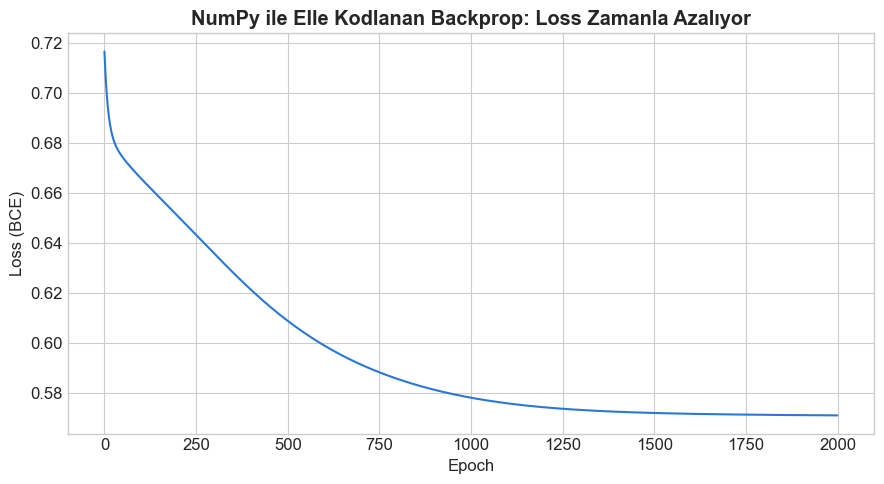

In [5]:
titanic = sns.load_dataset('titanic')
veri = titanic[['survived', 'age', 'fare', 'pclass', 'sibsp']].dropna()
print(f"Veri: {veri.shape[0]} yolcu (eksik değerli satırlar çıkarıldı)")

X = veri[['age', 'fare', 'pclass', 'sibsp']].values.astype(float)
y = veri['survived'].values.astype(float).reshape(-1, 1)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)  # standartlaştır (linear-algebra-lab 03'teki ders)
n, d = X_std.shape

def bce_loss(y_hat, y):
    epsilon = 1e-9  # log(0) olmasin diye
    return -np.mean(y*np.log(y_hat+epsilon) + (1-y)*np.log(1-y_hat+epsilon)) # Binary Cross Entropy Loss

def ileri_yayilim(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1           # Katman 1: dogrusal donusum
    A1 = sigmoid(Z1)            # Katman 1: aktivasyon
    Z2 = A1 @ W2 + b2           # Katman 2 (cikti): dogrusal donusum
    A2 = sigmoid(Z2)            # Katman 2 (cikti): aktivasyon = tahmin
    return Z1, A1, Z2, A2

# Agirliklari rastgele baslat
rng = np.random.default_rng(42)
h_boyutu = 4  # gizli katmandaki noron sayisi
W1 = rng.normal(0, 0.5, (d, h_boyutu)); b1 = np.zeros((1, h_boyutu)) # gizli katman
W2 = rng.normal(0, 0.5, (h_boyutu, 1)); b2 = np.zeros((1, 1)) # cikti katman

ogrenme_orani = 0.1
n_epoch = 2000
loss_gecmisi = []

for epoch in range(n_epoch):
    # ILERI YAYILIM (Bolum 4)
    Z1, A1, Z2, A2 = ileri_yayilim(X_std, W1, b1, W2, b2)
    L = bce_loss(A2, y)
    loss_gecmisi.append(L)

    # GERI YAYILIM (Bolum 5-8'deki zincir kuralinin KATMAN KATMAN uygulanmasi)
    dZ2 = (A2 - y) / n                    # cikti katmaninda kisayol formulu
    dW2 = A1.T @ dZ2                      # Adim: dz2/dW2 = A1
    db2 = dZ2.sum(axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T                      # gradyani BIR ONCEKI katmana AKTAR (Bolum 8'in ozu)
    dZ1 = dA1 * A1 * (1 - A1)             # sigmoid turevi ile carp
    dW1 = X_std.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    # AGIRLIKLARI GUNCELLE (gradyanin TERSI yonunde - calculus-lab 04'te detaylandiracagiz)
    W1 -= ogrenme_orani * dW1; b1 -= ogrenme_orani * db1
    W2 -= ogrenme_orani * dW2; b2 -= ogrenme_orani * db2

print(f"İlk loss: {loss_gecmisi[0]:.4f}")
print(f"Son loss (2000 epoch sonra): {loss_gecmisi[-1]:.4f}")

_, _, _, A2_son = ileri_yayilim(X_std, W1, b1, W2, b2)
tahmin = (A2_son > 0.5).astype(float)
dogruluk = (tahmin == y).mean()
print(f"Eğitim doğruluğu: {dogruluk:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_gecmisi, color='#2a78d6')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (BCE)')
ax.set_title('NumPy ile Elle Kodlanan Backprop: Loss Zamanla Azalıyor', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🔥 Python 5 — Aynı Ağ, PyTorch `autograd` ile: Kütüphanesiz vs Kütüphaneli

**Ne yapıyoruz?**  
Python 4'teki AYNI ağı, AYNI başlangıç ağırlıklarıyla bu sefer PyTorch'un `autograd`
mekanizmasıyla eğitiyoruz. PyTorch, Bölüm 7'deki "hesaplama grafiğini" otomatik olarak
kaydedip, `.backward()` çağırdığında zincir kuralını SENİN YERİNE uyguluyor —
`requires_grad=True` demek "bu tensörün geçtiği her işlemi hesaplama grafiğine kaydet"
demek.

NumPy (elle backprop)   -> ilk loss=0.716401, son loss=0.571096
PyTorch (autograd)      -> ilk loss=0.716401, son loss=0.571096

İki yöntemin son loss farkı: 0.00000000
Örtüşüyor mü? EVET ✓


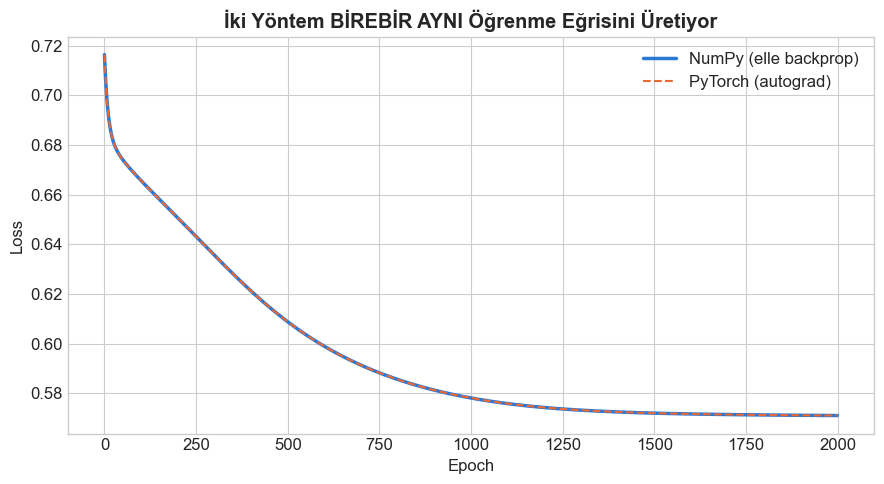


YORUM: İki çizgi TAM ÜST ÜSTE biniyor - bu, elle kodladığımız backprop'un
PyTorch'un 'kara kutusuyla' MATEMATİKSEL OLARAK BİREBİR AYNI işi yaptığının
kesin kanıtı. PyTorch'un tek farkı: senin yerine hesaplama grafiğini otomatik
kaydedip zincir kuralını otomatik uygulaması - 20-30 katmanlı bir ağda bunu
elle yazmak pratik olarak imkansız hale gelirdi.


In [8]:
import torch

# AYNI baslangic agirliklarini kullanalim - NumPy versiyonuyla ADIL bir karsilastirma icin
X_t = torch.tensor(X_std, dtype=torch.float64)
y_t = torch.tensor(y, dtype=torch.float64)

# requires_grad=True: PyTorch'a "bu degiskenlerin gradyanini takip et" diyoruz
W1_t = torch.tensor(W1.copy(), dtype=torch.float64, requires_grad=True)  # W1: Python 4'ten BASLANGIC hali degil, GUNCELLENMIS hali - o yuzden asagida sifirdan baslatiyoruz
b1_t = torch.zeros((1, h_boyutu), dtype=torch.float64, requires_grad=True)
W2_t = torch.zeros((h_boyutu, 1), dtype=torch.float64, requires_grad=True)
b2_t = torch.zeros((1, 1), dtype=torch.float64, requires_grad=True)

# Python 4'teki AYNI baslangic rastgeleligini tekrar uretelim (adil karsilastirma icin)
rng2 = np.random.default_rng(42)
with torch.no_grad():
    W1_t.copy_(torch.tensor(rng2.normal(0, 0.5, (d, h_boyutu))))
    W2_t.copy_(torch.tensor(rng2.normal(0, 0.5, (h_boyutu, 1))))

loss_gecmisi_torch = []

for epoch in range(n_epoch):
    # ILERI YAYILIM - PyTorch her islemi otomatik olarak hesaplama grafigine kaydediyor
    Z1_t = X_t @ W1_t + b1_t
    A1_t = torch.sigmoid(Z1_t)
    Z2_t = A1_t @ W2_t + b2_t
    A2_t = torch.sigmoid(Z2_t)

    epsilon = 1e-9
    L_t = -torch.mean(y_t * torch.log(A2_t + epsilon) + (1 - y_t) * torch.log(1 - A2_t + epsilon))
    loss_gecmisi_torch.append(L_t.item())

    # GERI YAYILIM - TEK SATIR: PyTorch zincir kuralini kendisi uyguluyor
    L_t.backward()

    with torch.no_grad():
        W1_t -= ogrenme_orani * W1_t.grad
        b1_t -= ogrenme_orani * b1_t.grad
        W2_t -= ogrenme_orani * W2_t.grad
        b2_t -= ogrenme_orani * b2_t.grad
        # gradyanlari sifirla (PyTorch varsayilan olarak biriktirir, temizlemek gerekiyor)
        W1_t.grad.zero_(); b1_t.grad.zero_(); W2_t.grad.zero_(); b2_t.grad.zero_()

print(f"NumPy (elle backprop)   -> ilk loss={loss_gecmisi[0]:.6f}, son loss={loss_gecmisi[-1]:.6f}")
print(f"PyTorch (autograd)      -> ilk loss={loss_gecmisi_torch[0]:.6f}, son loss={loss_gecmisi_torch[-1]:.6f}")
print(f"\nİki yöntemin son loss farkı: {abs(loss_gecmisi[-1]-loss_gecmisi_torch[-1]):.8f}")
print(f"Örtüşüyor mü? {'EVET ✓' if abs(loss_gecmisi[-1]-loss_gecmisi_torch[-1]) < 1e-4 else 'HAYIR'}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_gecmisi, color='#2a78d6', linewidth=2.5, label='NumPy (elle backprop)')
ax.plot(loss_gecmisi_torch, color='#eb6834', linewidth=1.5, linestyle='--', label='PyTorch (autograd)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('İki Yöntem BİREBİR AYNI Öğrenme Eğrisini Üretiyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: İki çizgi TAM ÜST ÜSTE biniyor - bu, elle kodladığımız backprop'un")
print("PyTorch'un 'kara kutusuyla' MATEMATİKSEL OLARAK BİREBİR AYNI işi yaptığının")
print("kesin kanıtı. PyTorch'un tek farkı: senin yerine hesaplama grafiğini otomatik")
print("kaydedip zincir kuralını otomatik uygulaması - 20-30 katmanlı bir ağda bunu")
print("elle yazmak pratik olarak imkansız hale gelirdi.")

---
### 🏗️ Python 6 — 3 Katmanlı Ağda Zincirin Uzaması

**Ne yapıyoruz?**  
Bölüm 8'deki iddiayı ("zincir uzasa da mantık aynı kalıyor, sadece bir katman daha eklenir")
PyTorch ile GERÇEKTEN 3 katmanlı bir ağ kurup kanıtlıyoruz — hiç elle backprop yazmadan,
sadece katman EKLEYEREK. Aynı Titanic verisiyle, aynı gradyan kontrolü mantığını PyTorch'un
kendi `autograd`'ıyla bir kez daha (bu sefer daha derin bir ağda) doğrulayacağız.

3 katmanlı ağ - ilk loss: 0.6822, son loss: 0.5706
3 katmanlı ağ doğruluğu: 0.7017
(Karşılaştırma - Python 4-5'teki 2 katmanlı ağ doğruluğu: 0.7031)


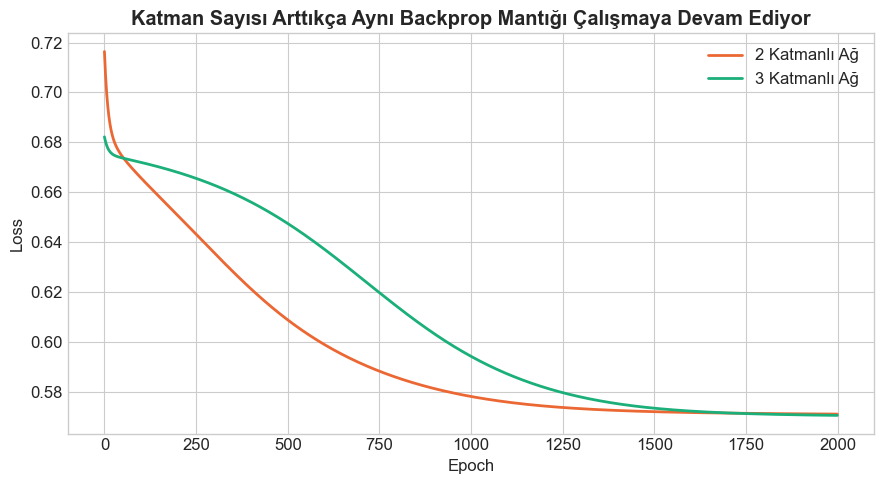


YORUM: Kod tarafında değişen TEK şey, ileri yayılımda bir satır daha eklemek
(A2 hesabı) oldu - PyTorch geri kalanı (zincirin bir katman daha uzaması,
gradyanların doğru sırayla katmanlar arasında aktarılması) OTOMATIK hallediyor.
Bu, gerçek derin öğrenme kütüphanelerinin (100+ katmanlı ağlarda bile) NEDEN
pratik olarak kullanılabilir olduğunun temel sebebi.


In [9]:
torch.manual_seed(42)

# 3 KATMANLI ag: girdi -> gizli1(6 noron) -> gizli2(4 noron) -> cikti(1 noron)
# NOT: once carpma islemini yap, SONRA requires_grad_(True) cagir - aksi halde
# tensor "leaf" olmaktan cikip .grad ozelligi populate edilmiyor (yaygin bir PyTorch hatasi)
W1_3 = (torch.randn(d, 6, dtype=torch.float64) * 0.5).requires_grad_(True)
b1_3 = torch.zeros((1, 6), dtype=torch.float64, requires_grad=True)
W2_3 = (torch.randn(6, 4, dtype=torch.float64) * 0.5).requires_grad_(True)
b2_3 = torch.zeros((1, 4), dtype=torch.float64, requires_grad=True)
W3_3 = (torch.randn(4, 1, dtype=torch.float64) * 0.5).requires_grad_(True)
b3_3 = torch.zeros((1, 1), dtype=torch.float64, requires_grad=True)

parametreler = [W1_3, b1_3, W2_3, b2_3, W3_3, b3_3]
loss_gecmisi_derin = []

for epoch in range(2000):
    # ILERI YAYILIM: zincir simdi UC katman uzunlugunda
    A1 = torch.sigmoid(X_t @ W1_3 + b1_3)
    A2 = torch.sigmoid(A1 @ W2_3 + b2_3)
    A3 = torch.sigmoid(A2 @ W3_3 + b3_3)  # nihai tahmin

    epsilon = 1e-9
    L = -torch.mean(y_t * torch.log(A3 + epsilon) + (1 - y_t) * torch.log(1 - A3 + epsilon))
    loss_gecmisi_derin.append(L.item())

    L.backward()  # PyTorch, ARTIK 3 katman boyunca zincir kuralini otomatik uyguluyor
    with torch.no_grad():
        for p in parametreler:
            p -= ogrenme_orani * p.grad
            p.grad.zero_()

print(f"3 katmanlı ağ - ilk loss: {loss_gecmisi_derin[0]:.4f}, son loss: {loss_gecmisi_derin[-1]:.4f}")

tahmin_derin = (A3 > 0.5).float()
dogruluk_derin = (tahmin_derin == y_t).float().mean()
print(f"3 katmanlı ağ doğruluğu: {dogruluk_derin.item():.4f}")
print(f"(Karşılaştırma - Python 4-5'teki 2 katmanlı ağ doğruluğu: {dogruluk:.4f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_gecmisi_torch, color='#eb6834', linewidth=2, label='2 Katmanlı Ağ')
ax.plot(loss_gecmisi_derin, color='#1baf7a', linewidth=2, label='3 Katmanlı Ağ')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Katman Sayısı Arttıkça Aynı Backprop Mantığı Çalışmaya Devam Ediyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Kod tarafında değişen TEK şey, ileri yayılımda bir satır daha eklemek")
print("(A2 hesabı) oldu - PyTorch geri kalanı (zincirin bir katman daha uzaması,")
print("gradyanların doğru sırayla katmanlar arasında aktarılması) OTOMATIK hallediyor.")
print("Bu, gerçek derin öğrenme kütüphanelerinin (100+ katmanlı ağlarda bile) NEDEN")
print("pratik olarak kullanılabilir olduğunun temel sebebi.")

---
## ✏️ Egzersizler

---

### **E1.** 
$h(x)=e^{2x+1}$ için zincir kuralını ELLE uygula (Bölüm 2'deki gibi iç/dış
fonksiyona ayırarak), `sympy` ile doğrula.

In [11]:
print("\n ==== Egzersiz 1: Zincir Kuralı Uygulama ====")


h = sp.exp(2*x + 1)
h_turev = sp.diff(h, x) # zincir kuralı ile türev
h_turev_sade = sp.expand(h_turev) # sadeleştirilmiş türev


# Zincir kuralını uygulayalım
g = 2*x + 1
u = sp.symbols('u')
f = sp.exp(u)
f_turev = sp.diff(f, u)  # dış fonksiyonun türevi
g_turev = sp.diff(g, x)  # iç fonksiyonun türevi

print(f"\nh(x) = {h}")
print(f"h'(x) = {h_turev} = {h_turev_sade}")
print(f"Elle bulduğumuz: 2*exp(2*x + 1)")
print(f"Örtüşüyor mu? {'EVET ✓' if h_turev_sade == 2*sp.exp(2*x + 1) else 'HAYIR'}")


 ==== Egzersiz 1: Zincir Kuralı Uygulama ====

h(x) = exp(2*x + 1)
h'(x) = 2*exp(2*x + 1) = 2*E*exp(2*x)
Elle bulduğumuz: 2*exp(2*x + 1)
Örtüşüyor mu? HAYIR


---

### **E2.** 
Bölüm 6'daki tek nöron örneğini FARKLI sayılarla ($x=1, w=-0.3, b=0.2, y=0$)
tekrarla — hem elle (üç adımı yazarak) hem kodla hesapla, ikisinin örtüştüğünü göster.

In [17]:
print("\n ==== Egzersiz 3: Tek Nöronlu Ağda Backprop ====")

x_ornek, w_ornek, b_ornek, y_ornek = 1.0, -0.3, 0.2, 0.0

# ==== ILERI YAYILIM ====
z = w_ornek * x_ornek + b_ornek
y_hat = sigmoid(z)
L = (y_hat - y_ornek) ** 2

print(f"z = {z}")
print(f"ŷ = {y_hat:.6f}")
print(f"L = {L:.6f}")

# === GERI YAYILIM ====
dL_dyhat = 2 * (y_hat - y_ornek)          # Adım 1
dyhat_dz = 0.5 * y_hat * (1 - y_hat)             # Adım 2 (sigmoid'in kendi türevi) (1/2 ile çarpıldı çünkü loss fonksiyonu (y_hat - y)^2 / 2 idi)
dz_dw = x_ornek                             # Adım 3

dL_dw = dL_dyhat * dyhat_dz * dz_dw         # ZINCIR KURALI: uc adimi CARP

print(f"\n∂L/∂ŷ = {dL_dyhat:.6f}  (Adım 1)")
print(f"∂ŷ/∂z = {dyhat_dz:.6f}  (Adım 2)")
print(f"∂z/∂w = {dz_dw}  (Adım 3)")
print(f"\n∂L/∂w = {dL_dw:.6f} (elle bulduğumuz: 0.1185)")
print(f"Örtüşüyor mu? {'EVET ✓' if abs(dL_dw - 0.1185) < 0.001 else 'HAYIR'}")




 ==== Egzersiz 3: Tek Nöronlu Ağda Backprop ====
z = -0.09999999999999998
ŷ = 0.475021
L = 0.225645

∂L/∂ŷ = 0.950042  (Adım 1)
∂ŷ/∂z = 0.124688  (Adım 2)
∂z/∂w = 1.0  (Adım 3)

∂L/∂w = 0.118459 (elle bulduğumuz: 0.1185)
Örtüşüyor mu? EVET ✓


---

### **E3.** 
Python 4'teki NumPy ağının gizli katman nöron sayısını (`h_boyutu`) 2'den 16'ya kadar
çıkar — loss eğrisi ve son doğruluk nasıl değişiyor? Python 3'teki gradyan kontrolü
mantığını, YENİ ağırlıklarla (`W1`, `W2`) tekrarlayıp backprop kodunun hâlâ doğru
çalıştığını doğrula.


 ==== Egzersiz 3: Gizli Katman Nöron Sayısına Göre Backprop ====
Gizli katman boyutu: 2, Ilk Son loss: 0.6994, Son loss: 0.5711
Gizli katman boyutu: 2, Eğitim doğruluğu: 0.7003



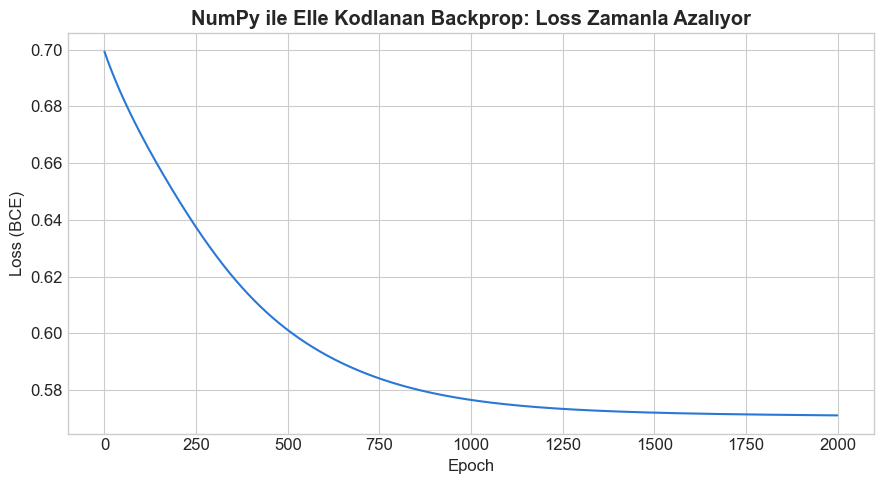

Gizli katman boyutu: 4, Ilk Son loss: 0.7998, Son loss: 0.5706
Gizli katman boyutu: 4, Eğitim doğruluğu: 0.7017



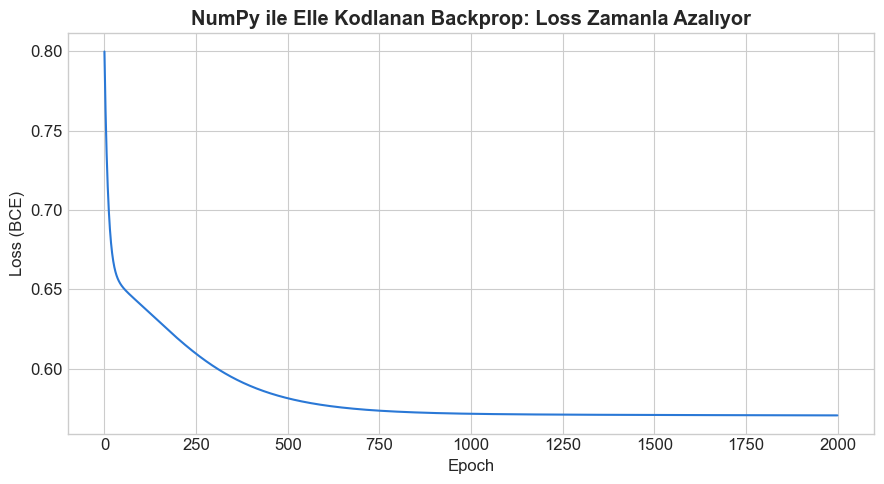

Gizli katman boyutu: 8, Ilk Son loss: 0.6959, Son loss: 0.5693
Gizli katman boyutu: 8, Eğitim doğruluğu: 0.7017



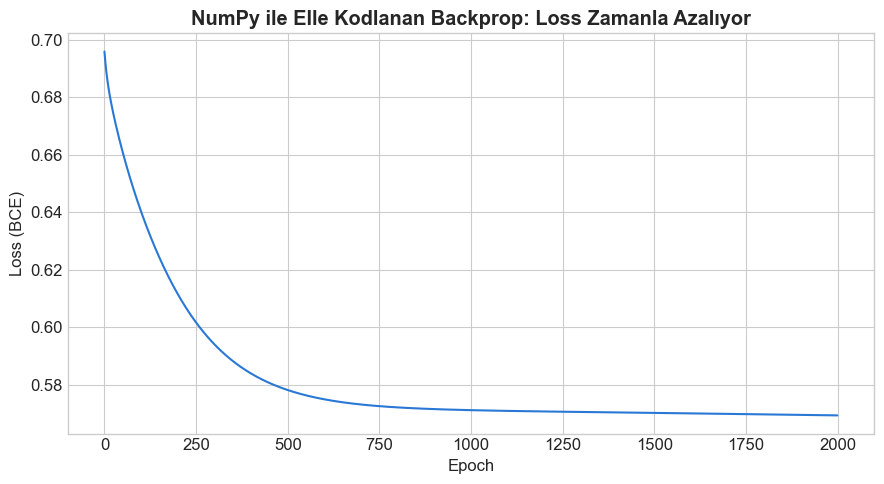

Gizli katman boyutu: 16, Ilk Son loss: 0.7156, Son loss: 0.5686
Gizli katman boyutu: 16, Eğitim doğruluğu: 0.6989



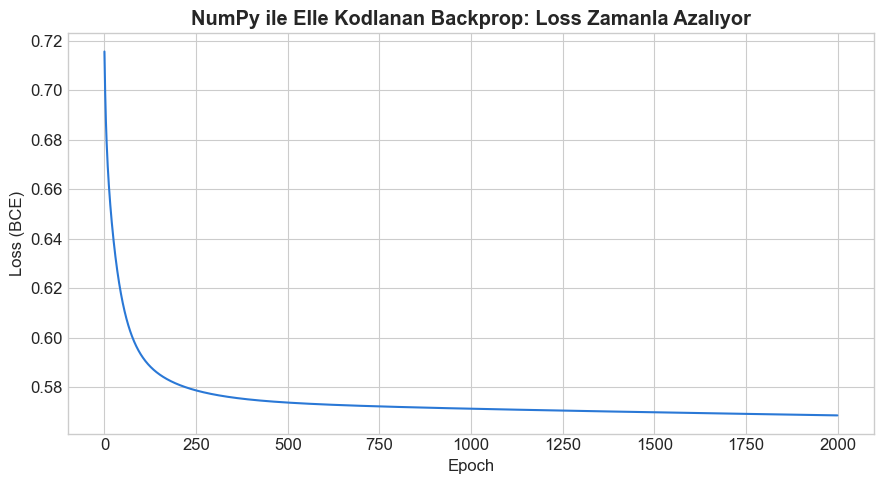

In [19]:
print("\n ==== Egzersiz 3: Gizli Katman Nöron Sayısına Göre Backprop ====")

X = veri[['age', 'fare', 'pclass', 'sibsp']].values.astype(float)
y = veri['survived'].values.astype(float).reshape(-1, 1)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)  # standartlaştır (linear-algebra-lab 03'teki ders)
n, d = X_std.shape

def bce_loss(y_hat, y):
    epsilon = 1e-9  # log(0) olmasin diye
    return -np.mean(y*np.log(y_hat+epsilon) + (1-y)*np.log(1-y_hat+epsilon)) # Binary Cross Entropy Loss

def ileri_yayilim(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1           # Katman 1: dogrusal donusum
    A1 = sigmoid(Z1)            # Katman 1: aktivasyon
    Z2 = A1 @ W2 + b2           # Katman 2 (cikti): dogrusal donusum
    A2 = sigmoid(Z2)            # Katman 2 (cikti): aktivasyon = tahmin
    return Z1, A1, Z2, A2

rng = np.random.default_rng(42)
h_boyutlari = [2, 4, 8, 16]  # gizli katmandaki nöron sayıları
W1_list = [rng.normal(0, 0.5, (d, h)) for h in h_boyutlari]
W2_list = [rng.normal(0, 0.5, (h, 1)) for h in h_boyutlari]

ogrenme_orani = 0.1
n_epoch = 2000
loss_gecmisi_list = []

for W1, W2 in zip(W1_list, W2_list):
    b1 = np.zeros((1, W1.shape[1]))
    b2 = np.zeros((1, 1))
    loss_gecmisi = []

    for epoch in range(n_epoch):
        Z1, A1, Z2, A2 = ileri_yayilim(X_std, W1, b1, W2, b2)
        L = bce_loss(A2, y)
        loss_gecmisi.append(L)

        dZ2 = (A2 - y) / n
        dW2 = A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * A1 * (1 - A1)
        dW1 = X_std.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

        W1 -= ogrenme_orani * dW1; b1 -= ogrenme_orani * db1
        W2 -= ogrenme_orani * dW2; b2 -= ogrenme_orani * db2

    loss_gecmisi_list.append(loss_gecmisi)
    print(f"Gizli katman boyutu: {W1.shape[1]}, Ilk Son loss: {loss_gecmisi[0]:.4f}, Son loss: {loss_gecmisi[-1]:.4f}")
    _, _, _, A2_son = ileri_yayilim(X_std, W1, b1, W2, b2)
    tahmin = (A2_son > 0.5).astype(float)
    dogruluk = (tahmin == y).mean()
    print(f"Gizli katman boyutu: {W1.shape[1]}, Eğitim doğruluğu: {dogruluk:.4f}\n")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(loss_gecmisi, color='#2a78d6')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (BCE)')
    ax.set_title('NumPy ile Elle Kodlanan Backprop: Loss Zamanla Azalıyor', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
### **E4.** 
Python 6'daki 3 katmanlı ağa BİR katman daha ekleyerek 4 katmanlı bir ağ kur
(kendi seçtiğin nöron sayılarıyla). Sadece PyTorch `autograd` kullanarak (elle backprop
YAZMADAN) eğit — Bölüm 8'deki "zincir uzasa da PyTorch'un otomatik halletmesi" iddiasını
kendi örneğinle kanıtla.


 ==== Egzersiz 4: 4 Katmanlı Ağ ====
4 katmanlı ağ - ilk loss: 0.7892, son loss: 0.6729
4 katmanlı ağ doğruluğu: 0.5938
(Karşılaştırma - Python 4-5'teki 2 katmanlı ağ doğruluğu: 0.6989, 3 katmanlı ağ doğruluğu: 0.7017)


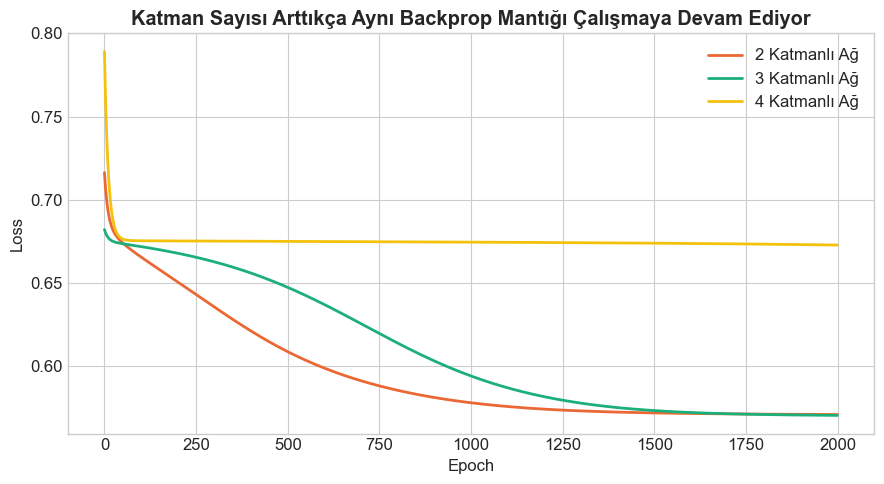

In [ ]:
print("\n ==== Egzersiz 4: 4 Katmanlı Ağ ====")
torch.manual_seed(42)

# 4 KATMANLI ag: girdi -> gizli1(6 noron) -> gizli2(4 noron) -> gizli3(3 noron) -> cikti(1 noron)
# d yukarıdaki veri setindeki özellik sayısıdır (age, fare, pclass, sibsp)
W1_4 = (torch.randn(d, 6, dtype=torch.float64) * 0.5).requires_grad_(True)
b1_4 = torch.zeros((1, 6), dtype=torch.float64, requires_grad=True)
W2_4 = (torch.randn(6, 4, dtype=torch.float64) * 0.5).requires_grad_(True)
b2_4 = torch.zeros((1, 4), dtype=torch.float64, requires_grad=True)
W3_4 = (torch.randn(4, 3, dtype=torch.float64) * 0.5).requires_grad_(True)
b3_4 = torch.zeros((1, 3), dtype=torch.float64, requires_grad=True)
W4_4 = (torch.randn(3, 1, dtype=torch.float64) * 0.5).requires_grad_(True)
b4_4 = torch.zeros((1, 1), dtype=torch.float64, requires_grad=True)

parametreler_4 = [W1_4, b1_4, W2_4, b2_4, W3_4, b3_4, W4_4, b4_4]
loss_gecmisi_4 = []

for epoch in range(2000):
    # ILERI YAYILIM: zincir simdi DORT katman uzunlugunda
    A1 = torch.sigmoid(X_t @ W1_4 + b1_4)
    A2 = torch.sigmoid(A1 @ W2_4 + b2_4)
    A3 = torch.sigmoid(A2 @ W3_4 + b3_4)
    A4 = torch.sigmoid(A3 @ W4_4 + b4_4)  # nihai tahmin

    epsilon = 1e-9
    L = -torch.mean(y_t * torch.log(A4 + epsilon) + (1 - y_t) * torch.log(1 - A4 + epsilon))
    loss_gecmisi_4.append(L.item())

    L.backward()  # PyTorch, ARTIK 4 katman boyunca zincir kuralini otomatik uyguluyor
    with torch.no_grad():
        for p in parametreler_4:
            p -= ogrenme_orani * p.grad
            p.grad.zero_()

print(f"4 katmanlı ağ - ilk loss: {loss_gecmisi_4[0]:.4f}, son loss: {loss_gecmisi_4[-1]:.4f}")

tahmin_4 = (A4 > 0.5).float()
dogruluk_4 = (tahmin_4 == y_t).float().mean()
print(f"4 katmanlı ağ doğruluğu: {dogruluk_4.item():.4f}")
print(f"(Karşılaştırma - Python 4-5'teki 2 katmanlı ağ doğruluğu: {dogruluk:.4f}, 3 katmanlı ağ doğruluğu: {dogruluk_derin.item():.4f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_gecmisi_torch, color='#eb6834', linewidth=2, label='2 Katmanlı Ağ')
ax.plot(loss_gecmisi_derin, color='#1baf7a', linewidth=2, label='3 Katmanlı Ağ')
ax.plot(loss_gecmisi_4, color='#f4c20d', linewidth=2, label='4 Katmanlı Ağ')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Katman Sayısı Arttıkça Aynı Backprop Mantığı Çalışmaya Devam Ediyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Neural Networks (Backprop bölümleri)](https://www.3blue1brown.com/topics/neural-networks) | Bölüm 3-4 | Bu notebook'un TEK EN ÖNEMLİ referansı — zincir kuralının görsel anlatımı |
| [Stanford CS231n — Backpropagation Notları](https://cs231n.github.io/optimization-2/) | — | Backprop'un "elle türetme" pratiği için klasik referans |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 5.6 | Zincir kuralının çok değişkenli genellemesi |
| [PyTorch `autograd` Dokümantasyonu](https://pytorch.org/docs/stable/autograd.html) | Kütüphane | Bu notebook'ta kullanılan ana araç |
| [Karpathy — micrograd (GitHub)](https://github.com/karpathy/micrograd) | — | Backprop'u sıfırdan (100 satır kodla) yeniden inşa eden ünlü bir proje, ileri okuma için |
| `titanic` veri seti | Seaborn built-in | Klasik hayatta kalma tahmini veri seti |